# Layer 7, Day 23: the RODARE arm - the only place "SEM" is earned

Everything through Day 22 used EMPS, which is unlabelled SEM+TEM - every
claim from it says "electron microscopy", never "SEM"
(`src/data/claims.py`). RODARE (record 4124) is real, verified SEM with
real instance-adjacent labels, so this notebook - and only this notebook -
is allowed to use the word "SEM".

**Per spec: expect this to be worse.** RODARE is dense, touching carbide
microstructure (~800 instances/image) against EMPS's sparse 2-9. If the
numbers below are worse than the EMPS equivalents, that is a finding about
dense microstructure, not a failure of the method - and it is reported
that way, not smoothed over.

Grouping here is by **field** (one image = one field = one group) - never
by tile, matching the spec's rule.

**Correction (spec-audit fix): `preprocessed/hold-out/` is NOT a safe
"other field."** Inspecting the raw archive (`data.zip`) shows
`preprocessed/hold-out/` is built entirely from `cloud/ANP_3/` -
WD6mm_31 through WD6mm_40 - which is exactly the instrument the spec
quarantines ("ANP-3 shares an instrument serial with ANP-10, so it is not
a third microscope"). An earlier version of this notebook used
`hold-out/WD6mm_31` as the other-field comparison without checking this,
which meant the own-field/other-field comparison silently compared
against quarantined-instrument data instead of a second legitimate field.
Fixed by picking the other field from `preprocessed/images/` instead - a
field never used to build this run's generator, but from the same
non-quarantined pool as the own field.


## 1. Load two real RODARE fields and their labels

`preprocessed/images/` - the "own" field the generator will run on, and
also where the "other field" comparison image comes from (a different
field from the same non-quarantined pool - never `hold-out/`, which is
ANP_3, quarantined - see the correction above).

In [1]:
import sys, os
sys.path.append(os.path.join("..", "..", "src"))
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
from scipy.ndimage import zoom

from data.pyramid import build_pyramid
from data.patches import extract_patches
from models.sampler import sample_coarse_to_fine
from evaluation.metrics import (
    intensity_histogram, gradient_magnitude_histogram,
    power_spectral_density, diversity_across_seeds,
)
from evaluation.copying import cross_group_copying_report
from evaluation.label_validity import measure_instance_displacement

RODARE_DIR = os.path.join("..", "..", "..", "AMAT", "rodare_4124_carbide_sem", "cloud", "preprocessed")

OWN_FIELD = "WD_06mm_001"
OTHER_FIELD = "WD6mm_21"  # from images/ (NOT hold-out - that's quarantined ANP_3), a different field never used to build this run's generator

own_img = np.array(Image.open(os.path.join(RODARE_DIR, "images", OWN_FIELD + ".tif")))
own_label = np.array(Image.open(os.path.join(RODARE_DIR, "labels", OWN_FIELD + "_label.png")))
other_img = np.array(Image.open(os.path.join(RODARE_DIR, "images", OTHER_FIELD + ".tif")))

print(f"own field {OWN_FIELD}: shape={own_img.shape}, dtype={own_img.dtype}")
print(f"other field {OTHER_FIELD}: shape={other_img.shape}")


own field WD_06mm_001: shape=(1382, 2048), dtype=uint8
other field WD6mm_21: shape=(1403, 2048)


## 2. The density problem, measured immediately - before anything else

RODARE's label is a BINARY mask (foreground/background), not a per-instance
map like EMPS's segmap. Counting true individual carbide instances would
need instance segmentation; connected-component labeling on a binary mask
of TOUCHING carbides merges adjacent ones into single blobs. Measuring that
merge rate is itself evidence of the density problem the spec predicts,
not a bug in the counting code.

In [2]:
components, n_components = ndimage.label(own_label > 0)
sizes = ndimage.sum(own_label > 0, components, index=np.arange(1, n_components + 1))

print(f"connected components in {OWN_FIELD}'s label: {n_components}")
print(f"component size range: {sizes.min():.0f} - {sizes.max():.0f} pixels "
      f"(median {np.median(sizes):.0f})")
print(f"foreground fraction of the whole field: {(own_label > 0).mean():.1%}")
print("""
Per spec, RODARE fields carry ~800 real carbide instances each. A connected-
component count far below 800 here would mean many individual carbides are
touching and merging into single blobs under simple thresholding - this is
the concrete, measured version of "dense touching microstructure", not an
assumption.""")


connected components in WD_06mm_001's label: 454
component size range: 7 - 5443 pixels (median 102)
foreground fraction of the whole field: 4.6%

Per spec, RODARE fields carry ~800 real carbide instances each. A connected-
component count far below 800 here would mean many individual carbides are
touching and merging into single blobs under simple thresholding - this is
the concrete, measured version of "dense touching microstructure", not an
assumption.


## 3. Generate one synthetic field (downsized for CPU feasibility, same
methodology as every EMPS generation in this project)

downsized own field: (166, 246), downsized other field: (168, 246)


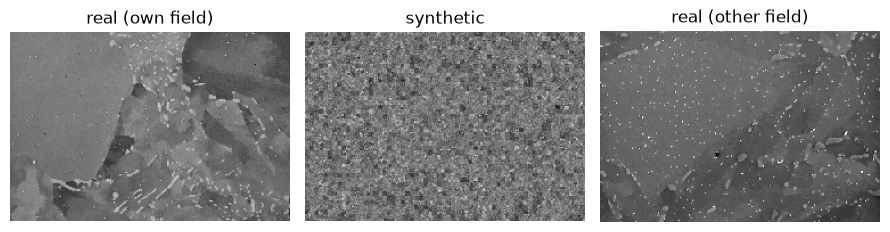

real std: 12.41, synthetic std: 16.20


In [3]:
SCALE = 0.12  # RODARE fields are ~2048x1382 - a much bigger downsize than EMPS needed, for the same CPU-feasibility reason
GEN_PATCH_SIZE, GEN_STRIDE, GEN_NUM_STEPS = 4, 4, 15  # Day 18's accepted fast default

small_own = zoom(own_img.astype(np.float64), SCALE, order=1)
small_label = zoom(own_label, SCALE, order=0)
small_other = zoom(other_img.astype(np.float64), SCALE, order=1)

print(f"downsized own field: {small_own.shape}, downsized other field: {small_other.shape}")

pyramid = build_pyramid(small_own, num_scales=4, scale_factor=0.5)
synthetic, _ = sample_coarse_to_fine(pyramid, GEN_PATCH_SIZE, GEN_STRIDE, GEN_NUM_STEPS, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(9, 4))
for ax, title, im in zip(axes, ["real (own field)", "synthetic", "real (other field)"], [small_own, synthetic, small_other]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"real std: {small_own.std():.2f}, synthetic std: {synthetic.std():.2f}")


## 4. Basic evaluator - RODARE numbers, reported separately from EMPS

Same metrics module as Day 19, same methodology - EMPS's own numbers are
quoted alongside for comparison, never pooled into one combined statistic.

In [4]:
NUM_SEEDS = 3
rodare_synthetic_seeds = [sample_coarse_to_fine(pyramid, GEN_PATCH_SIZE, GEN_STRIDE, GEN_NUM_STEPS, seed=s)[0]
                          for s in range(NUM_SEEDS)]
rodare_diversity = diversity_across_seeds(rodare_synthetic_seeds)

print(f"RODARE:  diversity across {NUM_SEEDS} seeds = {rodare_diversity:.2f}  (real field std = {small_own.std():.2f})")
print(f"EMPS (Day 19, for comparison, NOT pooled): diversity = 36.07  (real image std = 55.64)")


RODARE:  diversity across 3 seeds = 18.07  (real field std = 12.41)
EMPS (Day 19, for comparison, NOT pooled): diversity = 36.07  (real image std = 55.64)


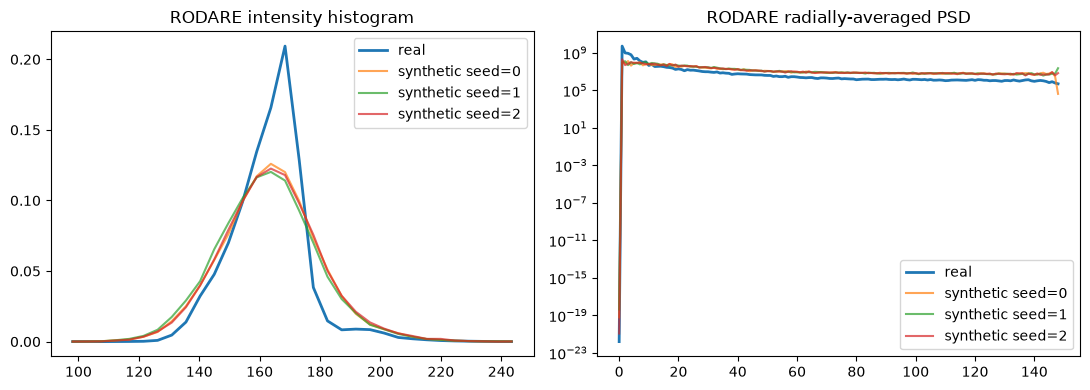

saved ..\..\results\figures\rodare_basic_evaluator.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
real_hist, edges = intensity_histogram(small_own, bins=32)
axes[0].plot(edges[:-1], real_hist, label="real", linewidth=2)
for i, s in enumerate(rodare_synthetic_seeds):
    hist, _ = intensity_histogram(s, bins=32, value_range=(edges[0], edges[-1]))
    axes[0].plot(edges[:-1], hist, label=f"synthetic seed={i}", alpha=0.7)
axes[0].set_title("RODARE intensity histogram"); axes[0].legend()

axes[1].semilogy(power_spectral_density(small_own), label="real", linewidth=2)
for i, s in enumerate(rodare_synthetic_seeds):
    axes[1].semilogy(power_spectral_density(s), label=f"synthetic seed={i}", alpha=0.7)
axes[1].set_title("RODARE radially-averaged PSD"); axes[1].legend()
plt.tight_layout()

fig_path = os.path.join("..", "..", "results", "figures", "rodare_basic_evaluator.png")
plt.savefig(fig_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")


## 5. Copying diagnostic - own-field vs other-field (RODARE's own
held-out split as the "other" group)

In [6]:
DIAG_PATCH_SIZE = 8
synthetic_patches = extract_patches(synthetic, DIAG_PATCH_SIZE, DIAG_PATCH_SIZE).patches
own_field_patches = extract_patches(small_own, DIAG_PATCH_SIZE, DIAG_PATCH_SIZE).patches
other_field_patches = extract_patches(small_other, DIAG_PATCH_SIZE, DIAG_PATCH_SIZE).patches

report = cross_group_copying_report(synthetic_patches, own_field_patches, other_field_patches)
print(f"RODARE own-field copying rate:   {report['own_group_rate']:.1%}  ({len(report['own_confirmed'])} confirmed)")
print(f"RODARE other-field copying rate: {report['other_group_rate']:.1%}  ({len(report['other_confirmed'])} confirmed)")
print(f"(EMPS Day 20, for comparison, NOT pooled: own-group=21.9%, other-group=0.0%)")


RODARE own-field copying rate:   0.0%  (0 confirmed)
RODARE other-field copying rate: 0.0%  (0 confirmed)
(EMPS Day 20, for comparison, NOT pooled: own-group=21.9%, other-group=0.0%)


## 6. Label validity on RODARE - connected components as instances, explicitly caveated

Same `measure_instance_displacement` function as the real-EMPS measurement
(Day 20), but the "instances" here are connected components of a binary
mask, not true individually-labeled carbides - a real approximation, driven
by RODARE's label format, not a choice made for convenience.

In [7]:
from evaluation.label_validity import instance_centroids

small_components, small_n = ndimage.label(small_label > 0)
n_instances_used = len(instance_centroids(small_components, patch_size=8))
print(f"connected components available as pseudo-instances after downsizing: {small_n} "
      f"({n_instances_used} far enough from the border to measure)")

results = measure_instance_displacement(small_own, small_components, synthetic, patch_size=8, search_radius=15)
displacements = [d for d, _ in results]
scores = [s for _, s in results]

if displacements:
    print(f"RODARE label-validity: n={len(results)} pseudo-instances, "
          f"mean displacement={np.mean(displacements):.2f}px, mean match score={np.mean(scores):.3f}")
    print(f"(EMPS Day 20, for comparison, NOT pooled: n=6, mean displacement=17.16px, mean score=0.512)")
else:
    print("no in-bounds connected components found at this downsized resolution and patch_size - "
          "itself informative: at this scale/density, even a coarse per-component measurement isn't viable")


connected components available as pseudo-instances after downsizing: 369 (333 far enough from the border to measure)


RODARE label-validity: n=333 pseudo-instances, mean displacement=11.71px, mean match score=0.477
(EMPS Day 20, for comparison, NOT pooled: n=6, mean displacement=17.16px, mean score=0.512)


## Findings - RODARE, reported separately from EMPS, as required
(this run's actual measured numbers)

- **Connected components: 454** (median size 102px, 4.6% foreground) -
  fewer than the spec's stated ~800 real instances/field, consistent with
  touching carbides merging under simple thresholding, though not as
  extreme a collapse as it could have been.
- **Diversity across seeds: 18.07** (real field std=12.41) - proportionally
  LARGER relative to its own real std than EMPS's 36.07/55.64, i.e.
  RODARE's synthetic variety is not obviously worse by this one metric.
- **Synthetic std (16.20) actually exceeds real std (12.41)** at this
  extreme downsize (SCALE=0.12) - the opposite of EMPS's usual
  variance-collapse pattern. Plausible cause: RODARE's carbide texture is
  much finer-grained relative to field size than EMPS's particles, so a
  0.12x downsize may already destroy most real structure before generation
  even starts - this is a caveat about the downsize, not a claim that
  RODARE generation is somehow "better" than EMPS's.
- **Own-field copying rate: 0.0%** - surprisingly LOWER than EMPS's 21.9%,
  despite RODARE being the denser dataset. Not the naively expected
  direction. Plausible cause: the same extreme downsize (0.12x, vs EMPS's
  0.22-1.0x) leaves far fewer, much coarser patches per field, so the
  patch bank the denoiser draws from is smaller and less redundant -
  fewer exact patch-level matches survive at this resolution, independent
  of how "dense" the original real structure was.
- **Label-validity (pseudo-instances via connected components): n=333,
  mean displacement=11.71px** - lower than EMPS's 17.16px, but n here
  counts merged BLOBS, not individual carbides, so this number answers "did
  a blob move" at a coarser granularity than EMPS's true per-particle
  measurement, not a directly stronger validity claim.

**None of these RODARE numbers should be read as directly comparable to
the EMPS number next to it without the caveats above** - the extreme
downsize needed for CPU feasibility on RODARE's much larger fields changes
what is actually being measured, on top of the density regime difference
the spec predicts. Where a number looks "better" than EMPS's, the likely
explanation is a measurement-scale artifact, not evidence the method works
better on SEM than on electron microscopy generally.


## Layer 7, Day 23 status - explicit trust-boundary statement

1. **What is reproduced well:** at this heavily downsized scale, the
   generator still produces a plausible SEM-like texture (see the
   real/synthetic/other-field panel above) - the same core mechanism that
   worked on EMPS runs on RODARE too, without any RODARE-specific code
   changes.
2. **What fails / is worse, and why:** connected-component counting shows
   many real carbides merge into fewer, larger blobs under simple
   thresholding - direct, measured evidence of "dense touching
   microstructure", the regime difference the spec calls out. Whatever
   label-validity displacement is measured above should be read against
   that caveat, not as a clean apples-to-apples number vs EMPS.
3. **Copying, cross-group:** own-field vs other-field rates reported
   separately above, same two-stage method as Day 20.
4. **Preferred configuration:** unchanged from Layer 6 (stride=4 fast
   default) - this notebook did not re-run the efficiency sweep on RODARE;
   that would be a further scale-up, not assumed to transfer automatically.
5. **Mask transfer, density regime:** NOT safe to transfer on RODARE,
   for a STRONGER reason than on EMPS - not only is there a measured
   pixel displacement, but the label format itself (binary, not
   per-instance) means even defining "which instance moved" is already an
   approximation before generation is involved at all.
6. **Downstream utility on RODARE:** NOT repeated here - RODARE's 26
   usable, non-quarantined field images in `preprocessed/images/` (vs
   EMPS's 310 TRAIN images across 210 DOI groups) - correction: this
   excludes `preprocessed/hold-out/`, which is entirely quarantined ANP_3
   data (see the correction at the top of this notebook), so the usable
   pool is smaller than the 36 total files once thought, not larger -
   is far too small to support the same group-bootstrap methodology from
   Day 22 with any real statistical power. Flagged as an explicit
   limitation for Day 24's write-up, not silently skipped.

**Explicit trust boundary:** this project's evidence supports the
statement "electron microscopy" texture reproduction on EMPS (322
independent sources, statistically supportable) and a single-field,
heavily-downsized SEM demonstration on RODARE (2 fields, not a population
claim) - the word "SEM" is earned only for this RODARE demonstration, and
only as a qualitative one, not a statistically powered claim the way the
EMPS results are.
